# 5. Spline templates and nuisance-profiled fits


    Replace repeated histogram filling with a parameterized template model.
    Compare spline predictions with independent construction-parameter anchors,
    then compare direct binned, spline binned, and unbinned profiled scans.
    Run notebooks 1–4 first.

### Runtime and persistent run

In Colab, choose **Runtime → Change runtime type → GPU** for notebooks 2–3.
Both PyTorch training and JAX likelihood fits use the GPU when available.
`JAX_BACKEND = "auto"` detects the Colab NVIDIA GPU; choose `"gpu"` to require it,
or `"cpu"` for an explicit CPU run. Setup installs matching JAX/JAXlib and CUDA 12
plugin packages, then checks double-precision JIT computation and gradients on
the selected device before training. GPU initialization failures are reported
instead of silently switching to CPU. Restart the runtime once when switching
from the previous CPU-only setup or after a JAX plugin error.
Keep the same run name: saved samples and trained networks are reused.
The source checkout lives in the temporary runtime; **datasets, checkpoints,
workspace files, and results live in Google Drive**. Use the same `RUN_NAME`
and `MODE` in every notebook. Set `MODE = "smoke"` for a short workflow check;
the production default generates five million events **per sample**.
Use `CONFIG_OVERRIDES` to change a computational budget without editing source,
for example `{"quadrature_per_process": 500_000, "epochs": 150}`. Use the same
overrides in all five notebooks, and choose a new `RUN_NAME` when changing them.

This repository may be private. Grant Colab access when opening it from GitHub.
For the runtime download, either save a GitHub fine-grained token with **Contents:
read** access to this repository as the Colab secret `GITHUB_TOKEN`, or enter it
in the hidden prompt. The token is used only in a Python HTTP header and is not
written into files, Git remotes, shell arguments, or notebook output. Alternatively,
upload a repository ZIP to `/content/poodemo_source.zip`; no token is then needed.
An existing `/content/poodemo` checkout is reused. Delete that checkout to fetch
new source after updating the repository; your Drive run is separate.
For this NI-only revision, use the new default `RUN_NAME = "demo-ni-v1"`.
If you ran an earlier version, start a fresh Colab runtime (or refresh the
temporary source checkout and restart the runtime) before proceeding. Existing
run manifests from the earlier model are incompatible and are not reused.

In [1]:
import os
import sys
from pathlib import Path

RUN_NAME = "demo-ni-v1"
MODE = os.environ.get("POODEMO_MODE", "production")  # production or smoke
CONFIG_OVERRIDES = {}  # e.g. {"quadrature_per_process": 500_000, "epochs": 150}
JAX_BACKEND = os.environ.get("POODEMO_JAX_BACKEND", "auto")  # auto, gpu, or cpu

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    requested_backend = JAX_BACKEND.strip().lower()
    if requested_backend not in ("auto", "gpu", "cpu"):
        raise ValueError("JAX_BACKEND must be auto, gpu, or cpu")
    selected_backend = requested_backend
    if requested_backend == "auto":
        try:
            gpu_probe = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                       capture_output=True, text=True, timeout=10)
            gpu_present = gpu_probe.returncode == 0 and bool(gpu_probe.stdout.strip())
        except (OSError, subprocess.TimeoutExpired):
            gpu_present = False
        selected_backend = "gpu" if gpu_present else "cpu"
    # CUDA-only selection fails visibly if initialization fails. Keep PyTorch's
    # CUDA visibility and avoid JAX reserving most GPU memory before training.
    jax_platform = "cuda" if selected_backend == "gpu" else "cpu"
    os.environ["JAX_PLATFORMS"] = jax_platform
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    ROOT = Path(os.environ.get("POODEMO_ROOT", f"/content/drive/MyDrive/poodemo/runs/{RUN_NAME}"))
    REPO_DIR = Path("/content/poodemo")
    if not (REPO_DIR / "pyproject.toml").exists():
        import getpass
        import io
        import shutil
        import tarfile
        import tempfile
        import urllib.error
        import urllib.request
        import zipfile

        uploaded_zip = Path("/content/poodemo_source.zip")
        if uploaded_zip.exists():
            archive_bytes = uploaded_zip.read_bytes()
            archive_kind = "zip"
        else:
            archive_url = "https://api.github.com/repos/rafaellopesdesa/poodemo/tarball/main"

            def fetch_source(token=None):
                headers = {"Accept": "application/vnd.github+json", "User-Agent": "poodemo-colab"}
                if token:
                    headers["Authorization"] = "Bearer " + token
                request = urllib.request.Request(archive_url, headers=headers)
                with urllib.request.urlopen(request, timeout=180) as response:
                    return response.read()

            try:
                archive_bytes = fetch_source()
            except urllib.error.HTTPError as error:
                if error.code not in (401, 403, 404):
                    raise RuntimeError(f"Repository download failed (HTTP {error.code}).") from None
                token = None
                try:
                    from google.colab import userdata
                    token = userdata.get("GITHUB_TOKEN")
                except Exception:
                    pass
                if not token:
                    token = getpass.getpass("GitHub token with read access to poodemo: ").strip()
                if not token:
                    raise RuntimeError("Upload /content/poodemo_source.zip or provide read access.")
                try:
                    archive_bytes = fetch_source(token)
                except urllib.error.HTTPError as auth_error:
                    raise RuntimeError(f"Repository download failed (HTTP {auth_error.code}); check token access.") from None
                finally:
                    token = None
            archive_kind = "tar"

        # Validate archive paths and reject links before extracting the source.
        with tempfile.TemporaryDirectory(prefix="poodemo-source-") as temp:
            staging = Path(temp).resolve()

            def safe_destination(name):
                destination = (staging / name).resolve()
                if not destination.is_relative_to(staging):
                    raise RuntimeError("Unsafe path in source archive.")
                return destination

            if archive_kind == "zip":
                with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
                    for entry in archive.infolist():
                        safe_destination(entry.filename)
                        if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                            raise RuntimeError("Symbolic links are not supported in the source ZIP.")
                    archive.extractall(staging)
            else:
                with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:gz") as archive:
                    for entry in archive.getmembers():
                        safe_destination(entry.name)
                        if not (entry.isfile() or entry.isdir()):
                            raise RuntimeError("Links and special files are not supported in the source archive.")
                    archive.extractall(staging)
            candidates = [p.parent for p in staging.rglob("pyproject.toml") if (p.parent / "poodemo").is_dir()]
            if len(candidates) != 1:
                raise RuntimeError("The uploaded archive must contain one poodemo repository checkout.")
            shutil.copytree(candidates[0], REPO_DIR, dirs_exist_ok=True)
        del archive_bytes

    if os.environ.get("POODEMO_SKIP_INSTALL") != "1":
        from importlib.metadata import version, PackageNotFoundError
        # JAX discovers every installed plugin, even when selecting CPU.
        # Retain already-matched CUDA 12 packages when rerunning GPU setup.
        remove_plugins = []
        for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt", "jax-cuda13-plugin", "jax-cuda13-pjrt"):
            try:
                installed_version = version(package)
            except PackageNotFoundError:
                continue
            if not (selected_backend == "gpu" and package.startswith("jax-cuda12-") and installed_version == "0.5.3"):
                remove_plugins.append(package)
        if remove_plugins:
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", *remove_plugins])
        gpu_requirements = (["jax==0.5.3", "jaxlib==0.5.3",
                             "jax-cuda12-plugin[with-cuda]==0.5.3", "jax-cuda12-pjrt==0.5.3"]
                            if selected_backend == "gpu" else [])
        # Resolve with the base requirements so PyTorch's CUDA dependencies are
        # considered together with JAX's. Avoid blanket --upgrade changes.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r",
                               str(REPO_DIR / "requirements-colab.txt"), *gpu_requirements])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)])

        # Check the live notebook kernel before any expensive network training.
        import jax
        import jaxlib
        import jax.numpy as jnp
        if jax.__version__ != "0.5.3" or jaxlib.__version__ != "0.5.3":
            raise RuntimeError("JAX packages are stale in this kernel. Restart the runtime and rerun setup.")
        if selected_backend == "gpu":
            for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt"):
                if version(package) != "0.5.3":
                    raise RuntimeError(f"{package} must match JAX 0.5.3. Restart the runtime and rerun setup.")
        jax.config.update("jax_platforms", jax_platform)
        jax.config.update("jax_enable_x64", True)
        try:
            jax_devices = jax.devices()
            if not jax_devices or any(device.platform != selected_backend for device in jax_devices):
                raise RuntimeError(f"Expected {selected_backend} devices; found {jax_devices}")
            probe_value, probe_gradient = jax.jit(jax.value_and_grad(lambda x: jnp.sum(x*x)))(
                jnp.asarray([1., 2., 3.], dtype=jnp.float64))
            probe_gradient.block_until_ready()
            if (float(probe_value) != 14. or list(probe_gradient) != [2., 4., 6.]
                    or probe_gradient.dtype != jnp.float64
                    or any(device.platform != selected_backend for device in probe_gradient.devices())):
                raise RuntimeError("JAX double-precision value/gradient check failed")
        except Exception as error:
            raise RuntimeError(
                f"JAX {selected_backend} startup failed. Select a Colab GPU runtime if requesting GPU, "
                "then restart the runtime and rerun setup. Use JAX_BACKEND='cpu' only for an intentional CPU run."
            ) from error
        print(f"JAX {jax.__version__} / jaxlib {jaxlib.__version__}: backend={selected_backend}, {jax_devices}; float64 JIT/gradient OK")

    # A new editable install is not activated in an already-running kernel.
    # Expose the inner package directly, including after a failed import cached
    # the outer /content/poodemo checkout as a namespace package.
    import importlib
    source_root = str(REPO_DIR.resolve())
    if source_root in sys.path:
        sys.path.remove(source_root)
    sys.path.insert(0, source_root)
    importlib.invalidate_caches()
    cached_package = sys.modules.get("poodemo")
    cached_file = getattr(cached_package, "__file__", None)
    expected_init = REPO_DIR / "poodemo" / "__init__.py"
    if cached_package is not None and (cached_file is None or Path(cached_file).resolve() != expected_init.resolve()):
        for module_name in list(sys.modules):
            if module_name == "poodemo" or module_name.startswith("poodemo."):
                del sys.modules[module_name]
else:
    # Locally: pip install -r requirements-colab.txt && pip install -e .
    ROOT = Path(os.environ.get("POODEMO_ROOT", str(Path.home() / "poodemo-runs" / RUN_NAME)))
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "poodemo" / "pipeline.py").exists():
            sys.path.insert(0, str(candidate))
            break

ROOT.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {ROOT}")
print(f"Mode: {MODE}")

Mounted at /content/drive


/tmp/ipykernel_1188/2609796805.py:110: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(staging)


JAX 0.5.3 / jaxlib 0.5.3: backend=gpu, [CudaDevice(id=0)]; float64 JIT/gradient OK
Run directory: /content/drive/MyDrive/poodemo/runs/demo-ni-v1
Mode: production


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from poodemo.pipeline import create_run

run = create_run(ROOT, mode=MODE, overrides=CONFIG_OVERRIDES)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.2})
display(pd.Series(run.config, name="configuration"))

,configuration
schema_version,3
mode,production
seed,20261006
toolkit_commit,fc09848fc6540fd32310faebbe9db6eea7ecd17b
n_per_sample,5000000
generation_chunk,250000
preselection_train_cap,1000000
ratio_train_cap,2000000
epochs,100
patience,20


### The spline coordinate is the construction parameter \(\eta\)

A process yield \(H_{jb}(\eta)\) in a fixed \(z\)-bin changes when
\(\eta\) changes because the observable moves events between bins.
The physical \(\mu\)-dependence still enters through the exact amplitude
coefficients. These two roles must stay separate:
\[
\nu_b(\mu;\eta)=(\mu-\sqrt\mu)H_{Sb}(\eta)
+\sqrt\mu H_{SBI,b}(\eta)+(1-\sqrt\mu)H_{Bb}(\eta)
+H_{NI,b}(\eta).
\]
Since the selected phase space is fixed and bins are exhaustive,
\(\sum_bH_{jb}(\eta)=\lambda_j\) is independent of \(\eta\).
We interpolate bin fractions with positivity and normalization enforced,
then restore the separate total yield. SBI interference enters through
the coherent templates, not an independently generated signed sample.

### Vary the templates, then interpolate the nuisance

Build nominal and ±1 templates for NI and nominal templates for S, B,
and SBI. Fit their dependence on \(\eta\).
At any construction point, evaluate the splines first; then use the
same exponential–polynomial rule to interpolate in \(\alpha_{NI}\).
Every profiled fit retains the Gaussian auxiliary constraint
\(\exp(-\alpha_{NI}^2/2)\), or \(+\alpha_{NI}^2\) in \(-2\log L\).

The Asimov data histogram also depends on \(\eta\) and is refilled from
the integration events at each tested point, rather than interpolated.
All nuisance fits keep \(\eta=\mu_0\) fixed
in both numerator and denominator.

Integration and nonlinear nuisance interpolation generally do not
commute:
\[
\int_{B_b(\eta)}\!\mathrm{Interp}_{\alpha_{NI}}[D(x)]\,dx
\ne \mathrm{Interp}_{\alpha_{NI}}\!\left[\int_{B_b(\eta)}D(x)\,dx\right].
\]
This difference is recorded separately from spline interpolation error.
Agreement at nominal and ±1 templates alone does not establish equality
between the continuously morphed unbinned and binned models.

In [3]:
from poodemo.pipeline import run_spline_study

splines = run_spline_study(run)
display(splines['validation'])
display(splines['yields'])

Spline and direct profile fits at eta=0.1 ready
Spline and direct profile fits at eta=0.172 ready
Spline and direct profile fits at eta=0.245 ready
Spline and direct profile fits at eta=0.318 ready
Spline and direct profile fits at eta=0.39 ready
Spline and direct profile fits at eta=0.463 ready
Spline and direct profile fits at eta=0.535 ready
Spline and direct profile fits at eta=0.607 ready
Spline and direct profile fits at eta=0.68 ready
Spline and direct profile fits at eta=0.752 ready
Spline and direct profile fits at eta=0.825 ready
Spline and direct profile fits at eta=0.897 ready
Spline and direct profile fits at eta=0.97 ready
Spline and direct profile fits at eta=1 ready
Spline and direct profile fits at eta=1.04 ready
Spline and direct profile fits at eta=1.11 ready
Spline and direct profile fits at eta=1.19 ready
Spline and direct profile fits at eta=1.26 ready
Spline and direct profile fits at eta=1.33 ready
Spline and direct profile fits at eta=1.41 ready
Spline and dire

,eta,sample,variation,max_fraction_error,l1_fraction_error
0,0.124167,S,nominal,0.004618,0.040530
1,0.124167,SBI,nominal,0.004381,0.021950
2,0.124167,B,nominal,0.005023,0.021997
3,0.124167,NI,nominal,0.052344,0.104910
4,0.124167,S,NI_down,0.004618,0.040530
...,...,...,...,...,...
727,2.975833,NI,NI_down,0.000126,0.000320
728,2.975833,S,NI_up,0.000253,0.001257
729,2.975833,SBI,NI_up,0.000085,0.000475
730,2.975833,B,NI_up,0.000055,0.000296


,eta,sample,variation,bin,yield_value
0,0.1,S,nominal,0,0.0
1,0.1,S,nominal,1,0.0
2,0.1,S,nominal,2,0.0
3,0.1,S,nominal,3,0.0
4,0.1,S,nominal,4,0.0
...,...,...,...,...,...
95227,3.0,NI,NI_up,123,0.0
95228,3.0,NI,NI_up,124,0.0
95229,3.0,NI,NI_up,125,0.0
95230,3.0,NI,NI_up,126,0.0


The binning is chosen from notebook 4: use the smallest tested bin count
retaining at least 99% of the extended Fisher information at every
tested anchor. If none passes, use the finest tested binning and report
the residual loss. The splines are shape-preserving piecewise cubic
Hermite interpolants (PCHIP) of nonnegative bin fractions, followed by
explicit normalization. This preserves zero-valued anchors without a
logarithmic floor. Queries that differ from an anchor only by
floating-point roundoff reuse its stored bin fractions, so nominal
and varied templates keep their exact empty-bin support. No
extrapolation beyond the anchor range is permitted.

,eta,sample,variation,bin,yield_value
0,0.1,S,nominal,0,0.0
1,0.1,S,nominal,1,0.0
2,0.1,S,nominal,2,0.0
3,0.1,S,nominal,3,0.0
4,0.1,S,nominal,4,0.0
5,0.1,S,nominal,5,0.0
6,0.1,S,nominal,6,0.0
7,0.1,S,nominal,7,0.0
8,0.1,S,nominal,8,0.0
9,0.1,S,nominal,9,0.0


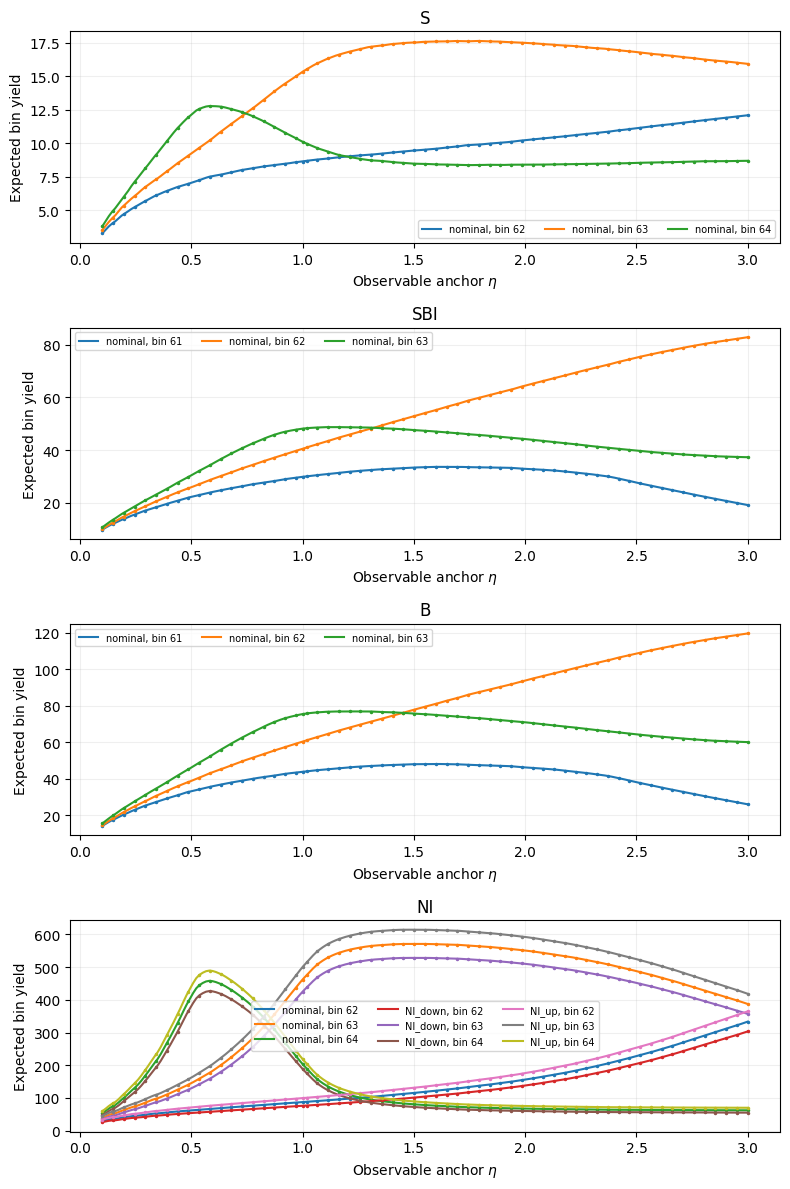

In [4]:
from poodemo.data import PROCESSES

yields = splines["yields"]
display(yields.head(20))
# Points are histogram anchors; lines are interpolated expected yields.
spline = splines["spline"]
eta_dense = np.linspace(spline.etas[0], spline.etas[-1], 200)
dense_yields = spline(eta_dense)
variation_order = ["nominal", "NI_down", "NI_up"]
processes = list(yields["sample"].unique())
fig, axes = plt.subplots(len(processes), 1, figsize=(8, 3 * len(processes)), squeeze=False)
for process, ax in zip(processes, axes[:, 0]):
    subset = yields[yields["sample"] == process]
    shown_bins = subset.groupby("bin")["yield_value"].sum().nlargest(3).index
    variations = ["nominal"] + (["NI_down", "NI_up"] if process == "NI" else [])
    subset = subset[subset["bin"].isin(shown_bins) & subset["variation"].isin(variations)]
    for (variation, bin_number), values in subset.groupby(["variation", "bin"], sort=False):
        values = values.sort_values("eta")
        curve = dense_yields[:, variation_order.index(variation), PROCESSES.index(process), int(bin_number)]
        line, = ax.plot(eta_dense, curve, label=f"{variation}, bin {bin_number}")
        ax.plot(values["eta"], values["yield_value"], ".", ms=3, color=line.get_color())
    ax.set(xlabel=r"Observable anchor $\eta$", ylabel="Expected bin yield", title=process)
    ax.legend(fontsize=7, ncol=3)
fig.tight_layout()
(ROOT / "plots").mkdir(exist_ok=True)
fig.savefig(ROOT / "plots" / "05_template_yields.pdf", bbox_inches="tight")
plt.show()

For comparison, the next plot fixes \(\eta=1\) and varies the **physical**
\(\mu\). This dependence comes from the signal/interference coefficients,
not from the spline. The two plots answer different questions.

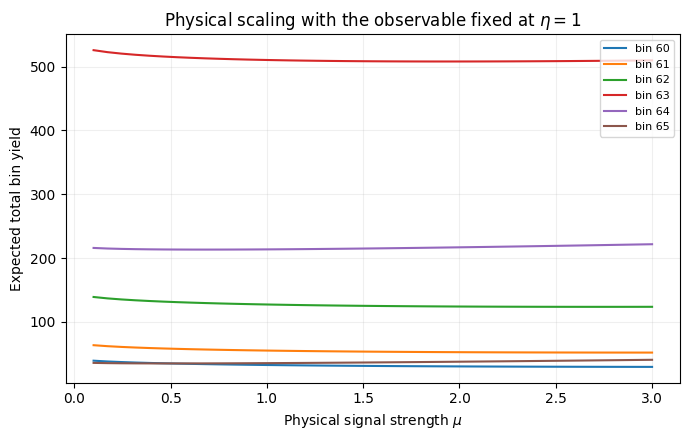

In [5]:

physical = splines["physical_yields"]
shown_bins = physical.groupby("bin")["yield_value"].sum().nlargest(6).index
fig, ax = plt.subplots()
for bin_number, values in physical[physical["bin"].isin(shown_bins)].groupby("bin"):
    ax.plot(values["mu"], values["yield_value"], label=f"bin {bin_number}")
ax.set(xlabel=r"Physical signal strength $\mu$", ylabel="Expected total bin yield",
       title=r"Physical scaling with the observable fixed at $\eta=1$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / "plots" / "05_physical_bin_yields.pdf", bbox_inches="tight")
plt.show()

In [6]:
def plot_scans(frame, title, filename, group_columns=None):
    """Plot saved scan tables; adapt grouping to the columns present."""
    x_column = next((c for c in ["mu", "mu_test", "mu0"] if c in frame.columns), None)
    y_column = next((c for c in ["q", "t_mu", "test_statistic", "ts"] if c in frame.columns), None)
    if x_column is None or y_column is None:
        raise ValueError(f"Expected mu and q scan columns; found {list(frame.columns)}")
    if group_columns is None:
        group_columns = [c for c in ["method", "model", "systematics", "nuisances", "n_bins", "bins", "observable"] if c in frame.columns]
    groups = frame.groupby(group_columns, dropna=False, sort=False) if group_columns else [("scan", frame)]
    fig, ax = plt.subplots()
    for label, group in groups:
        group = group.sort_values(x_column)
        values = label if isinstance(label, tuple) else (label,)
        parts = []
        for column, value in zip(group_columns, values):
            if pd.isna(value):
                continue
            if column == "systematics":
                parts.append("profiled" if value else "stat only")
            elif column in ("n_bins", "bins"):
                parts.append(f"{int(value)} bins")
            else:
                parts.append(str(value))
        ax.plot(group[x_column], group[y_column], marker=".", ms=3, label=" | ".join(parts))
    ax.axhline(1.0, color="0.45", ls=":", lw=1)
    ax.set(xlabel=r"Tested signal strength $\mu_0$", ylabel=r"$t(\mu_0)$", title=title)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    fig.tight_layout()
    output = ROOT / "plots"
    output.mkdir(exist_ok=True)
    fig.savefig(output / filename, bbox_inches="tight")
    plt.show()
    return fig

,mu,model,systematics,q,valid,mu_hat,alpha_NI,fit_message,eta,n_bins,edm
0,0.1000,direct score histogram,False,7.373029,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.1000,128.0,NaN
1,0.1000,direct score histogram,True,6.290893,True,1.0,-0.380251,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGT...,0.1000,128.0,NaN
2,0.1000,spline score histogram,False,7.373029,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.1000,128.0,NaN
3,0.1000,spline score histogram,True,6.290893,True,1.0,-0.380251,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.1000,128.0,NaN
4,0.1725,direct score histogram,False,6.879357,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.1725,128.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
331,2.7100,learned unbinned,True,21.236156,True,NaN,-0.277843,NaN,NaN,NaN,1.753200e-09
332,2.7825,learned unbinned,True,22.883601,True,NaN,-0.291909,NaN,NaN,NaN,2.259567e-09
333,2.8550,learned unbinned,True,24.580447,True,NaN,-0.306073,NaN,NaN,NaN,2.867232e-09
334,2.9275,learned unbinned,True,26.325758,True,NaN,-0.320331,NaN,NaN,NaN,3.595215e-09


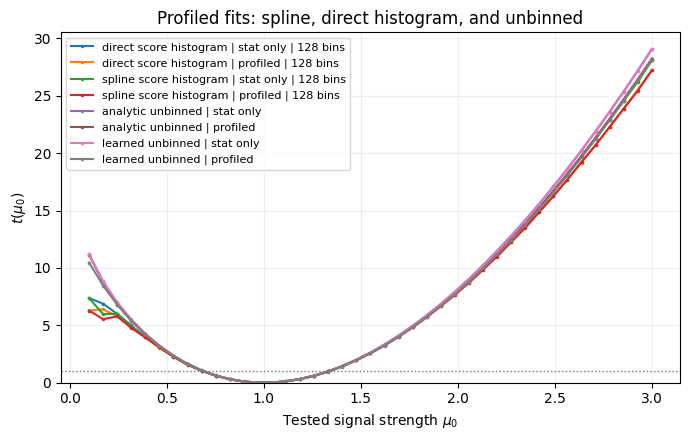

,mu,systematics,q_direct,mu_hat_direct,q_spline,mu_hat_spline,delta_q,is_spline_anchor
0,0.1000,False,7.373029,1.0,7.373029,1.000000,0.000000e+00,True
1,0.1000,True,6.290893,1.0,6.290893,1.000000,8.881784e-16,True
2,0.1725,False,6.879357,1.0,5.974553,0.919321,-9.048037e-01,False
3,0.1725,True,6.406968,1.0,5.532812,0.920125,-8.741561e-01,False
4,0.2450,False,5.999114,1.0,5.999114,1.000000,-1.776357e-15,True
...,...,...,...,...,...,...,...,...
79,2.8550,True,23.872157,1.0,23.872157,1.000000,-1.278977e-13,True
80,2.9275,False,26.311071,1.0,26.220478,1.002946,-9.059305e-02,False
81,2.9275,True,25.521914,1.0,25.429873,1.002945,-9.204144e-02,False
82,3.0000,False,28.090466,1.0,28.090466,1.000000,1.456613e-13,True


Largest spline/direct test-statistic difference: 0.9048037355126777


In [7]:
display(splines['scans'])
plot_scans(splines['scans'], 'Profiled fits: spline, direct histogram, and unbinned', '05_profiled_scans.pdf');
display(splines['comparison'])
print('Largest spline/direct test-statistic difference:', splines['comparison']['delta_q'].abs().max())

### Read the comparisons separately

- **Spline vs direct histogram:** tests amortization of the moving
  observable, using construction points withheld from the spline fit.
- **Coarse vs fine direct histograms:** tests finite binning.
- **Binned nuisance interpolation vs integrated unbinned interpolation:**
  tests the distinction between two morphing prescriptions.
- **Learned vs analytical unbinned:** tests ratio estimation.
- **Score histograms vs the full unbinned model:** includes the effects
  of scalar compression, particularly when \(\alpha_{NI}\) is profiled.

A scalar \(\mu\)-score at \(\alpha_{NI}=0\) does not automatically
preserve all profiled information. A joint score vector, or a suitable
efficient score, is a natural extension. This example measures the
agreement obtained by the requested scalar construction.

In [8]:
print("All stages finished. Results are stored under:", ROOT)
print("Use a new RUN_NAME for a changed configuration or a fresh statistical study.")
for key, value in splines.items():
    if key not in ("scans", "yields", "validation", "spline"):
        print(key)
        display(value)

All stages finished. Results are stored under: /content/drive/MyDrive/poodemo/runs/demo-ni-v1
Use a new RUN_NAME for a changed configuration or a fresh statistical study.
physical_yields


,mu,eta,bin,yield_value
0,0.1,1.0,0,0.0
1,0.1,1.0,1,0.0
2,0.1,1.0,2,0.0
3,0.1,1.0,3,0.0
4,0.1,1.0,4,0.0
...,...,...,...,...
5371,3.0,1.0,123,0.0
5372,3.0,1.0,124,0.0
5373,3.0,1.0,125,0.0
5374,3.0,1.0,126,0.0


morph_comparison


,eta,alpha_NI,l1_relative_difference,nll_difference
0,0.10,-1.0,1.546972e-16,1.421085e-14
1,0.10,-0.5,3.846957e-06,-2.444783e-05
2,0.10,0.5,4.006430e-06,-6.162720e-05
3,0.10,1.0,1.737033e-16,-2.486900e-14
4,0.10,1.5,2.035715e-05,1.038041e-03
5,1.55,-1.0,9.804986e-17,-1.065814e-14
6,1.55,-0.5,5.690042e-06,-1.753863e-04
7,1.55,0.5,4.785167e-06,-2.972473e-04
8,1.55,1.0,1.591685e-16,-2.842171e-14
9,1.55,1.5,2.899081e-05,2.476741e-03


comparison


,mu,systematics,q_direct,mu_hat_direct,q_spline,mu_hat_spline,delta_q,is_spline_anchor
0,0.1000,False,7.373029,1.0,7.373029,1.000000,0.000000e+00,True
1,0.1000,True,6.290893,1.0,6.290893,1.000000,8.881784e-16,True
2,0.1725,False,6.879357,1.0,5.974553,0.919321,-9.048037e-01,False
3,0.1725,True,6.406968,1.0,5.532812,0.920125,-8.741561e-01,False
4,0.2450,False,5.999114,1.0,5.999114,1.000000,-1.776357e-15,True
...,...,...,...,...,...,...,...,...
79,2.8550,True,23.872157,1.0,23.872157,1.000000,-1.278977e-13,True
80,2.9275,False,26.311071,1.0,26.220478,1.002946,-9.059305e-02,False
81,2.9275,True,25.521914,1.0,25.429873,1.002945,-9.204144e-02,False
82,3.0000,False,28.090466,1.0,28.090466,1.000000,1.456613e-13,True


n_bins


128

### Further experiments

Increase the integration statistics to test numerical stability; widen
the scan to expose interference effects; compare a fixed \(\eta=1\)
score with the moving score; or add nuisance-score components. An
interval-coverage study would require genuine pseudo-experiments and
calibration of the chosen statistic, beyond these Asimov comparisons.